In [56]:
import os
import gc
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from tabulate import tabulate
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [58]:
class EEGDataset(Dataset):
    def __init__(
        self,
        npz_path: str,
        normalize: bool = True,
        eps: float = 1e-8
    ):
        data = np.load(npz_path)

        if "X" not in data or "y" not in data:
            raise KeyError("File npz phải chứa 2 key: 'X' và 'y'")

        self.X = data["X"].astype(np.float32)   # (N, C, T)
        self.y = data["y"].astype(np.int64)     # (N,)

        if self.X.ndim != 3:
            raise ValueError(f"X phải có shape (N, C, T), nhưng nhận được {self.X.shape}")
        if self.y.ndim != 1:
            raise ValueError(f"y phải có shape (N,), nhưng nhận được {self.y.shape}")
        if len(self.X) != len(self.y):
            raise ValueError(f"Số lượng sample X ({len(self.X)}) và y ({len(self.y)}) không khớp")

        self.normalize = normalize
        self.eps = eps

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]   # (C, T)
        y = self.y[idx]

        if self.normalize:
            x_min = x.min(axis=1, keepdims=True)   # (C, 1)
            x_max = x.max(axis=1, keepdims=True)   # (C, 1)
            x = 2.0 * (x - x_min) / (x_max - x_min + self.eps) - 1.0

        x = torch.from_numpy(x).float()            # (C, T)
        y = torch.tensor(y, dtype=torch.long)

        return {
            "signal": x,
            "label": y
        }

In [59]:
train_npz = "/kaggle/input/datasets/hnguyentt/chb01-loso-30mins/chb01/fold_test_sid_6/train.npz"
val_npz   = "/kaggle/input/datasets/hnguyentt/chb01-loso-30mins/chb01/fold_test_sid_6/validation.npz"
test_npz   = "/kaggle/input/datasets/hnguyentt/chb01-loso-30mins/chb01/fold_test_sid_6/test.npz"

In [60]:
train_dataset = EEGDataset(
    npz_path=train_npz,
    normalize=True,
)

val_dataset = EEGDataset(
    npz_path=val_npz,
    normalize=True,
)

test_dataset = EEGDataset(
    npz_path=test_npz,
    normalize=True,
)

In [61]:
import random
import matplotlib.pyplot as plt

i = 0              # sample thứ i
channel_idx = 0    # kênh muốn xem

data_item = train_dataset[i]

x = data_item["signal"][channel_idx].numpy()   # (T,)
y = data_item["label"].item()

print("Shape:", x.shape)
print("Min:", x.min())
print("Max:", x.max())

Shape: (2048,)
Min: -1.0
Max: 0.99991417


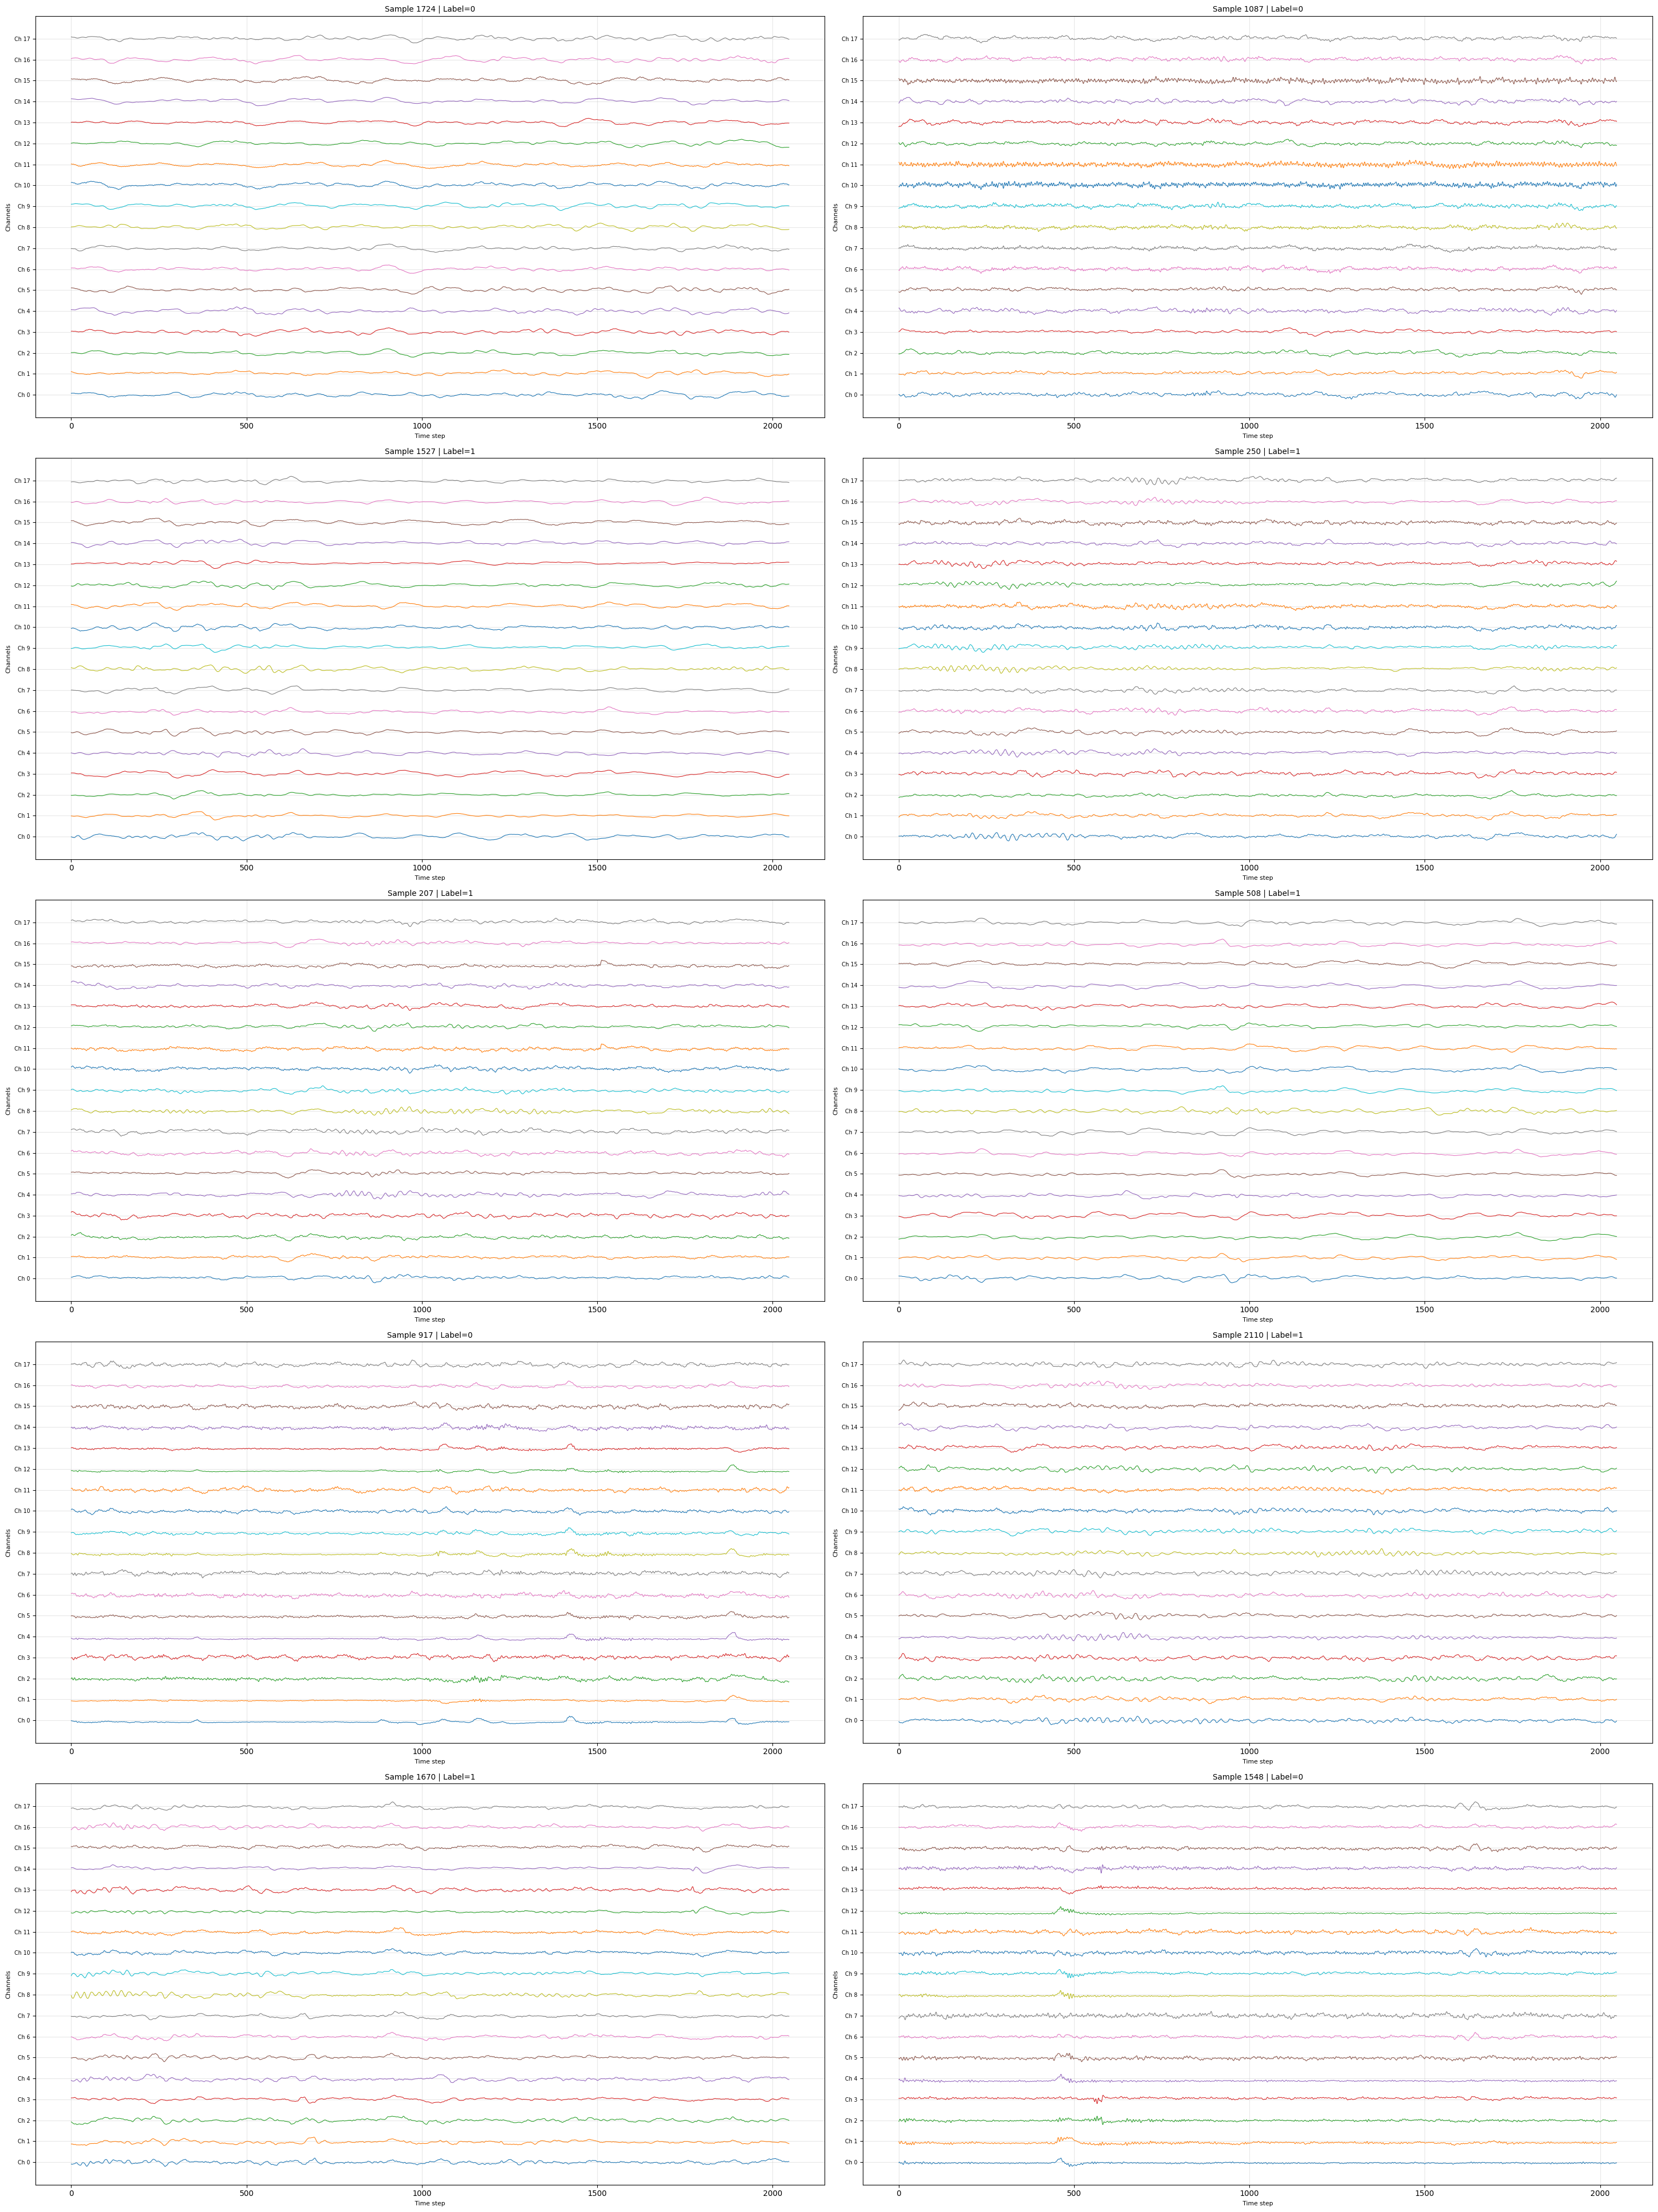

In [62]:
num_show = 10
offset = 5.0

# lấy ngẫu nhiên 10 sample khác nhau
indices = random.sample(range(len(train_dataset)), num_show)

fig, axes = plt.subplots(5, 2, figsize=(30, 40))
axes = axes.flatten()

for ax, i in zip(axes, indices):
    data_item = train_dataset[i]
    signal = data_item["signal"].numpy()   # (C, T)
    y = data_item["label"].item()

    num_channels, T = signal.shape

    for ch in range(num_channels):
        ax.plot(signal[ch] + ch * offset, linewidth=0.8)

    ax.set_yticks([ch * offset for ch in range(num_channels)])
    ax.set_yticklabels([f"Ch {ch}" for ch in range(num_channels)], fontsize=7)
    ax.set_title(f"Sample {i} | Label={y}", fontsize=10)
    ax.set_xlabel("Time step", fontsize=8)
    ax.set_ylabel("Channels", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
train_labels = train_dataset.y
class_counts = np.bincount(train_labels)
print("Train class counts:", class_counts)

Train class counts: [1340 1340]


In [64]:
# from torch.utils.data import DataLoader, WeightedRandomSampler
# import torch
# import numpy as np

# class_weights = 1.0 / class_counts
# sample_weights = class_weights[train_labels]
# sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)

# sampler = WeightedRandomSampler(
#     weights=sample_weights,
#     num_samples=len(sample_weights),
#     replacement=True
# )

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=1028,
#     sampler=sampler,
#     num_workers=2,
#     pin_memory=True,
#     drop_last=True,
# )

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    drop_last=True,
)


val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
)

In [65]:
class EEGPatchEmbedding(nn.Module):
    def __init__(self, in_channels: int, seq_len: int, patch_size: int, d_model: int):
        super().__init__()

        assert seq_len % patch_size == 0, "seq_len phải chia hết cho patch_size"

        self.in_channels = in_channels
        self.seq_len = seq_len
        self.patch_size = patch_size
        self.num_patches = seq_len // patch_size
        self.patch_dim = in_channels * patch_size

        # Linear projection: từ patch_dim -> d_model
        self.proj = nn.Linear(self.patch_dim, d_model)

    def forward(self, x):
        """
        x: (B, C, T)
        return: (B, num_patches, d_model)
        """
        B, C, T = x.shape

        # Chia theo patch thời gian
        x = x.view(B, C, self.num_patches, self.patch_size)   # (B, C, P, patch)
        x = x.permute(0, 2, 1, 3).contiguous()                # (B, P, C, patch)
        x = x.view(B, self.num_patches, self.patch_dim)       # (B, P, C*patch)

        # Chiếu sang không gian embedding
        x = self.proj(x)                                      # (B, P, d_model)
        return x

class LearnablePositionalEncoding(nn.Module):
    def __init__(self, num_patches: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, d_model))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, num_patches, d_model)
        """
        x = x + self.pos_embed
        x = self.dropout(x)
        return x
    

class EEGTransformerEncoder(nn.Module):
    def __init__(
        self,
        d_model: int,
        nhead: int,
        num_layers: int,
        dim_feedforward: int = 256,
        dropout: float = 0.1
    ):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,   # rất quan trọng: input sẽ là (B, seq, d_model)
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers
        )

    def forward(self, x):
        """
        x: (B, num_patches, d_model)
        """
        x = self.encoder(x)
        return x

class MeanPooling(nn.Module):
    def forward(self, x):
        """
        x: (B, num_patches, d_model)
        return: (B, d_model)
        """
        return x.mean(dim=1)
    
class ClassificationHead(nn.Module):
    def __init__(self, d_model: int, num_classes: int, dropout: float = 0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        """
        x: (B, d_model)
        """
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

class EEGTransformerClassifier(nn.Module):
    def __init__(
        self,
        in_channels: int = 18,
        seq_len: int = 2048,
        patch_size: int = 32,
        d_model: int = 128,
        nhead: int = 4,
        num_layers: int = 3,
        dim_feedforward: int = 256,
        num_classes: int = 2,
        dropout: float = 0.1
    ):
        super().__init__()

        assert seq_len % patch_size == 0, "seq_len phải chia hết cho patch_size"
        num_patches = seq_len // patch_size

        self.patch_embed = EEGPatchEmbedding(
            in_channels=in_channels,
            seq_len=seq_len,
            patch_size=patch_size,
            d_model=d_model
        )

        self.pos_encoding = LearnablePositionalEncoding(
            num_patches=num_patches,
            d_model=d_model,
            dropout=dropout
        )

        self.encoder = EEGTransformerEncoder(
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )

        self.pool = MeanPooling()

        self.head = ClassificationHead(
            d_model=d_model,
            num_classes=num_classes,
            dropout=dropout
        )

    def forward(self, x):
        """
        x: (B, C, T)
        """
        x = self.patch_embed(x)     # (B, P, d_model)
        x = self.pos_encoding(x)    # (B, P, d_model)
        x = self.encoder(x)         # (B, P, d_model)
        x = self.pool(x)            # (B, d_model)
        x = self.head(x)            # (B, num_classes)
        return x

In [66]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Train", leave=False)

    for batch in pbar:
        signal = batch["signal"].to(device, non_blocking=True)
        label = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(signal)
        loss = criterion(logits, label)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * signal.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(label.detach().cpu().numpy())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return {
        "loss": epoch_loss,
        "acc": acc,
        "bal_acc": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [67]:
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Val", leave=False)

    for batch in pbar:
        signal = batch["signal"].to(device, non_blocking=True)
        label = batch["label"].to(device, non_blocking=True)

        logits = model(signal)
        loss = criterion(logits, label)

        running_loss += loss.item() * label.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(label.cpu().numpy().tolist())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, zero_division=0)

    return {
        "loss": epoch_loss,
        "acc": acc,
        "bal_acc": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cm": cm,
        "report": report
    }

In [68]:
model = EEGTransformerClassifier(
        in_channels = 18,
        seq_len = 2048,
        patch_size = 8,
        d_model = 128,
        nhead = 8,
        num_layers = 3,
        dim_feedforward = 512,
        num_classes = 2,
        dropout = 0.2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [69]:
num_epochs = 50
best_val_f1 = -1.0

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch + 1}/{num_epochs}]")

    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = validate(model, val_loader, criterion, device)

    table = [
        [
            "Train",
            f"{train_metrics['loss']:.4f}",
            f"{train_metrics['acc']:.4f}",
            f"{train_metrics['bal_acc']:.4f}",
            f"{train_metrics['precision']:.4f}",
            f"{train_metrics['recall']:.4f}",
            f"{train_metrics['f1']:.4f}",
        ],
        [
            "Val",
            f"{val_metrics['loss']:.4f}",
            f"{val_metrics['acc']:.4f}",
            f"{val_metrics['bal_acc']:.4f}",
            f"{val_metrics['precision']:.4f}",
            f"{val_metrics['recall']:.4f}",
            f"{val_metrics['f1']:.4f}",
        ],
    ]

    print(tabulate(
        table,
        headers=["Split", "Loss", "Acc", "Bal Acc", "Precision", "Recall", "F1"],
        tablefmt="grid"
    ))

    print("Val confusion matrix:")
    print(val_metrics["cm"])
    print("Val classification report:")
    print(val_metrics["report"])

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), "best_eegnet_30m.pth")
        print("Saved best model.")


Epoch [1/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.5796 | 0.6803 |    0.6801 |      0.6825 |   0.6801 | 0.6791 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.5451 | 0.7428 |    0.7428 |      0.7766 |   0.7428 | 0.7347 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[255 194]
 [ 37 412]]
Val classification report:
              precision    recall  f1-score   support

           0       0.87      0.57      0.69       449
           1       0.68      0.92      0.78       449

    accuracy                           0.74       898
   macro avg       0.78      0.74      0.73       898
weighted avg       0.78      0.74      0.73       898

Saved best model.

Epoch [2/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.5247 | 0.7321 |    0.7319 |      0.7365 |   0.7319 | 0.7307 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.5373 | 0.7416 |    0.7416 |      0.7821 |   0.7416 | 0.732  |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[248 201]
 [ 31 418]]
Val classification report:
              precision    recall  f1-score   support

           0       0.89      0.55      0.68       449
           1       0.68      0.93      0.78       449

    accuracy                           0.74       898
   macro avg       0.78      0.74      0.73       898
weighted avg       0.78      0.74      0.73       898


Epoch [3/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.5208 | 0.737  |    0.7368 |      0.7419 |   0.7368 | 0.7356 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.5301 | 0.7428 |    0.7428 |      0.7807 |   0.7428 | 0.7338 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[251 198]
 [ 33 416]]
Val classification report:
              precision    recall  f1-score   support

           0       0.88      0.56      0.68       449
           1       0.68      0.93      0.78       449

    accuracy                           0.74       898
   macro avg       0.78      0.74      0.73       898
weighted avg       0.78      0.74      0.73       898


Epoch [4/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.5135 | 0.7405 |    0.7402 |      0.7482 |   0.7402 | 0.7383 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.527  | 0.7416 |    0.7416 |      0.7758 |   0.7416 | 0.7334 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[254 195]
 [ 37 412]]
Val classification report:
              precision    recall  f1-score   support

           0       0.87      0.57      0.69       449
           1       0.68      0.92      0.78       449

    accuracy                           0.74       898
   macro avg       0.78      0.74      0.73       898
weighted avg       0.78      0.74      0.73       898


Epoch [5/50]


...

+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.2718 | 0.8815 |    0.8814 |      0.8835 |   0.8814 | 0.8813 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.3603 | 0.8452 |    0.8452 |      0.8763 |   0.8452 | 0.842  |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[315 134]
 [  5 444]]
Val classification report:
              precision    recall  f1-score   support

           0       0.98      0.70      0.82       449
           1       0.77      0.99      0.86       449

    accuracy                           0.85       898
   macro avg       0.88      0.85      0.84       898
weighted avg       0.88      0.85      0.84       898


Epoch [47/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.2819 | 0.8674 |    0.8673 |      0.8687 |   0.8673 | 0.8672 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.3362 | 0.8541 |    0.8541 |      0.879  |   0.8541 | 0.8517 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[326 123]
 [  8 441]]
Val classification report:
              precision    recall  f1-score   support

           0       0.98      0.73      0.83       449
           1       0.78      0.98      0.87       449

    accuracy                           0.85       898
   macro avg       0.88      0.85      0.85       898
weighted avg       0.88      0.85      0.85       898


Epoch [48/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.2716 | 0.8841 |    0.8841 |      0.8854 |   0.8841 | 0.884  |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.2923 | 0.8731 |    0.8731 |      0.8909 |   0.8731 | 0.8716 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[344 105]
 [  9 440]]
Val classification report:
              precision    recall  f1-score   support

           0       0.97      0.77      0.86       449
           1       0.81      0.98      0.89       449

    accuracy                           0.87       898
   macro avg       0.89      0.87      0.87       898
weighted avg       0.89      0.87      0.87       898


Epoch [49/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.2749 | 0.8788 |    0.8787 |      0.881  |   0.8787 | 0.8786 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.2878 | 0.8719 |    0.8719 |      0.8909 |   0.8719 | 0.8704 |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[342 107]
 [  8 441]]
Val classification report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       449
           1       0.80      0.98      0.88       449

    accuracy                           0.87       898
   macro avg       0.89      0.87      0.87       898
weighted avg       0.89      0.87      0.87       898


Epoch [50/50]


+---------+--------+--------+-----------+-------------+----------+--------+
| Split   |   Loss |    Acc |   Bal Acc |   Precision |   Recall |     F1 |
+=========+========+========+===========+=============+==========+========+
| Train   | 0.2537 | 0.8921 |    0.8921 |      0.8932 |   0.8921 | 0.8921 |
+---------+--------+--------+-----------+-------------+----------+--------+
| Val     | 0.3504 | 0.8508 |    0.8508 |      0.8787 |   0.8508 | 0.848  |
+---------+--------+--------+-----------+-------------+----------+--------+
Val confusion matrix:
[[321 128]
 [  6 443]]
Val classification report:
              precision    recall  f1-score   support

           0       0.98      0.71      0.83       449
           1       0.78      0.99      0.87       449

    accuracy                           0.85       898
   macro avg       0.88      0.85      0.85       898
weighted avg       0.88      0.85      0.85       898



In [70]:
import torch
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)


def load_model_checkpoint(model, checkpoint_path, device, strict=True):
    """
    Load checkpoint vào model.
    Hỗ trợ 2 kiểu lưu phổ biến:
    1. torch.save(model.state_dict(), path)
    2. torch.save({"model_state_dict": model.state_dict(), ...}, path)
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict):
        if "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]
        elif "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]
        else:
            # trường hợp checkpoint chính là state_dict
            state_dict = checkpoint
    else:
        raise ValueError("Checkpoint không hợp lệ. Không đọc được state_dict.")

    # Nếu model được train bằng DataParallel thì key có tiền tố 'module.'
    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    model.load_state_dict(state_dict, strict=strict)
    model.to(device)
    model.eval()

    return model


@torch.no_grad()
def evaluate_test(model, test_loader, criterion, device, checkpoint_path, strict=True, target_names=None):
    """
    Load model từ checkpoint rồi evaluate trên tập test.
    """
    model = load_model_checkpoint(model, checkpoint_path, device, strict=strict)

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(test_loader, desc="Test", leave=False)

    for batch in pbar:
        # Giả sử model của bạn chỉ nhận signal, nếu có image/fusion thì thêm vào đây
        signal = batch["signal"].to(device, non_blocking=True)
        label = batch["label"].to(device, non_blocking=True)

        logits = model(signal)

        if criterion is not None:
            loss = criterion(logits, label)
            running_loss += loss.item() * label.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(label.cpu().numpy().tolist())

    epoch_loss = running_loss / len(test_loader.dataset) if criterion is not None else 0.0

    # Tính toán các chỉ số cơ bản
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    
    # Tính Precision, Recall, F1 (Macro)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    # Tính Confusion Matrix để trích xuất Sensitivity và Specificity
    cm = confusion_matrix(all_labels, all_preds)
    
    # Đối với bài toán nhị phân (0: Interictal, 1: Preictal)
    # cm.ravel() sẽ trả về: tn, fp, fn, tp
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        # Trường hợp multi-class hoặc dữ liệu thiếu class khi test
        sensitivity = recall_macro
        specificity = 0.0 # Cần định nghĩa riêng cho multi-class nếu cần

    report = classification_report(
        all_labels,
        all_preds,
        target_names=target_names,
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "acc": acc,
        "bal_acc": bal_acc,
        "precision": precision_macro,
        "recall": recall_macro,
        "f1": f1_macro,
        "sensitivity": sensitivity,   # Thêm mới
        "specificity": specificity,   # Thêm mới
        "cm": cm,
        "report": report,
        "preds": all_preds,
        "labels": all_labels
    }

In [71]:
from tabulate import tabulate

checkpoint_path = "/kaggle/working/best_eegnet_30m.pth"

test_results = evaluate_test(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    checkpoint_path=checkpoint_path,
    strict=True,
    target_names=['Interictal', 'Preictal']
)

# Chuẩn bị dữ liệu bảng
table = [
    [
        "Test",
        f"{test_results.get('loss', 0):.4f}",
        f"{test_results['acc']:.4f}",
        f"{test_results['bal_acc']:.4f}",
        f"{test_results['precision']:.4f}",
        f"{test_results['sensitivity']:.4f}", # Độ nhạy
        f"{test_results['specificity']:.4f}", # Độ đặc hiệu
        f"{test_results['f1']:.4f}",
    ]
]

headers = [
    "Split", 
    "Total Loss", 
    "Acc", 
    "Bal Acc", 
    "Precision", 
    "Sen", 
    "Spe", 
    "F1"
]

print(tabulate(table, headers=headers, tablefmt="grid"))
print("\nTest confusion matrix:")
print(test_results["cm"])
print("\nTest classification report:")
print(test_results["report"])

+---------+--------------+--------+-----------+-------------+--------+--------+--------+
| Split   |   Total Loss |    Acc |   Bal Acc |   Precision |    Sen |    Spe |     F1 |
+=========+==============+========+===========+=============+========+========+========+
| Test    |       0.8139 | 0.6763 |    0.6763 |        0.68 | 0.6049 | 0.7478 | 0.6747 |
+---------+--------------+--------+-----------+-------------+--------+--------+--------+

Test confusion matrix:
[[335 113]
 [177 271]]

Test classification report:
              precision    recall  f1-score   support

  Interictal       0.65      0.75      0.70       448
    Preictal       0.71      0.60      0.65       448

    accuracy                           0.68       896
   macro avg       0.68      0.68      0.67       896
weighted avg       0.68      0.68      0.67       896

